# Logistic Regression

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

#### 1. Data Exploration:

In [21]:
data = pd.read_csv("diabetes.csv")
print("Data loaded. Shape:", data.shape)

Data loaded. Shape: (768, 9)


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [23]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [24]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [25]:
data.duplicated().sum()

np.int64(0)

#### Histograms

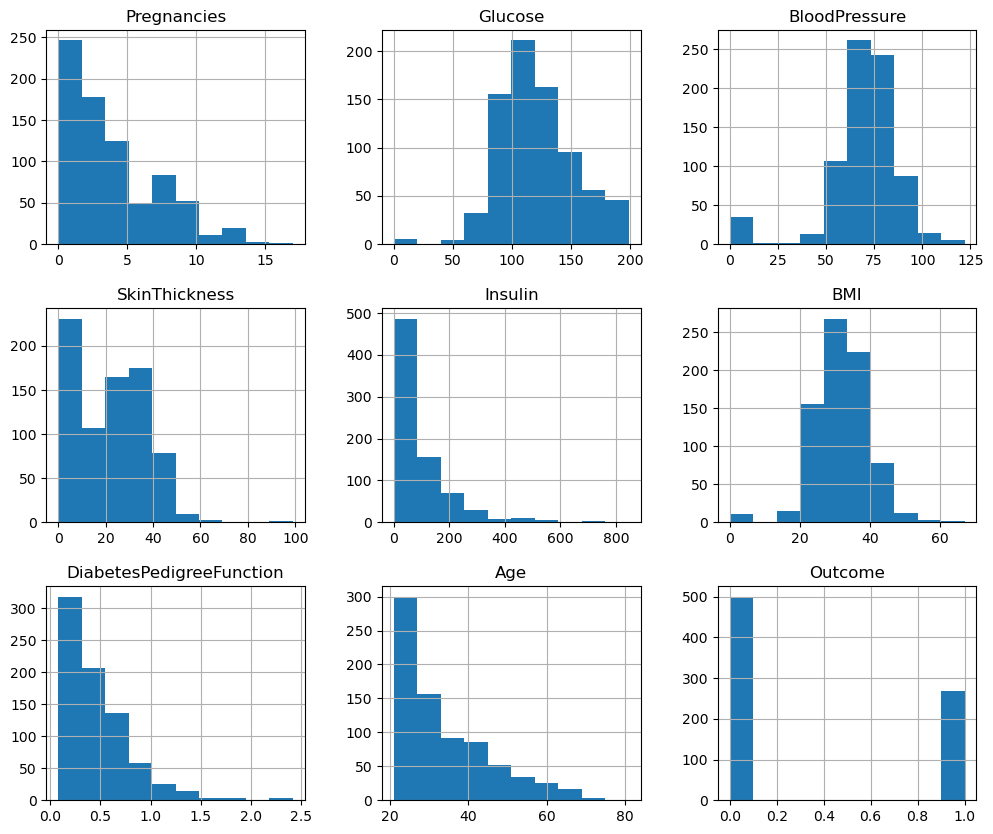

In [26]:
data.hist(figsize=(12,10))
plt.show()

#### Boxplot

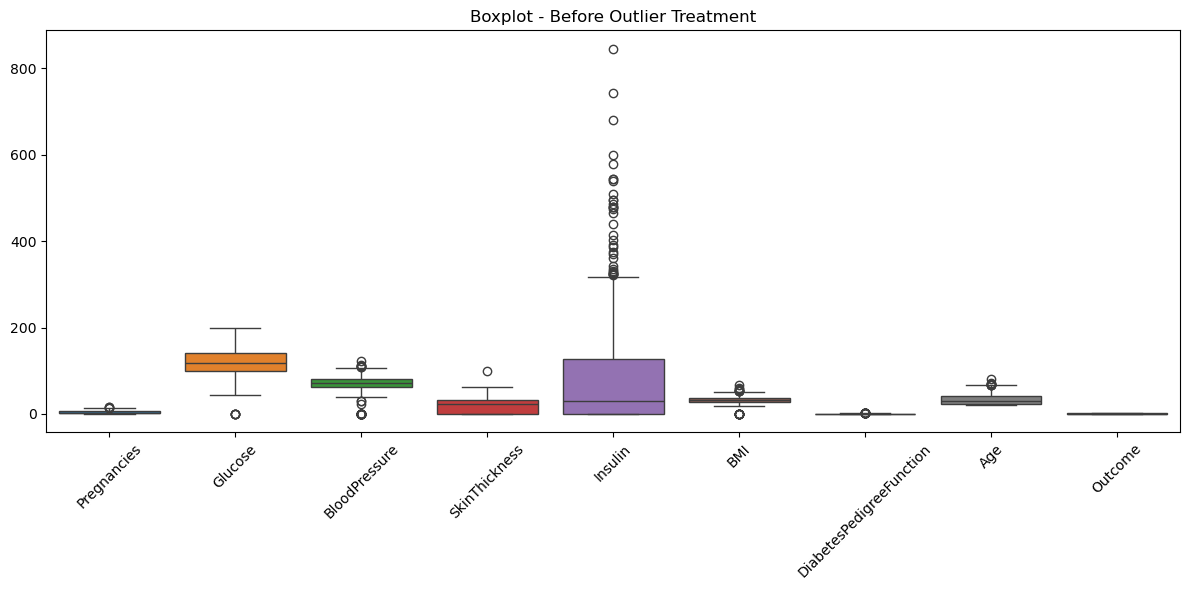

In [27]:
## Boxplot BEFORE Outlier Treatment
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.title('Boxplot - Before Outlier Treatment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Correlation Heatmap

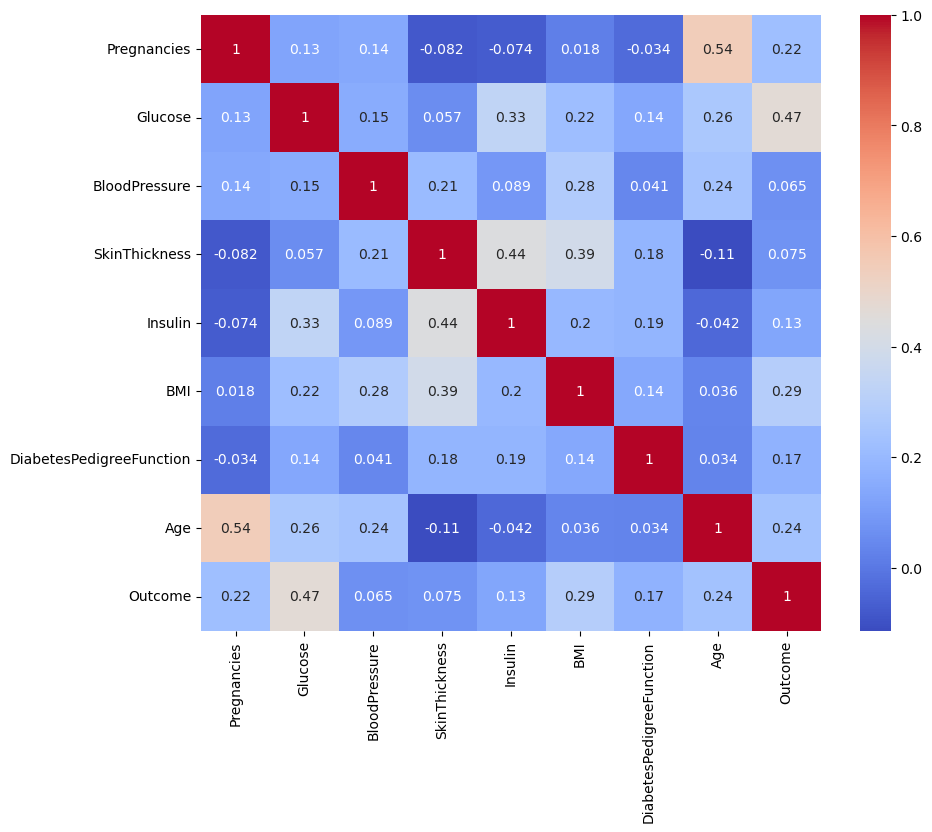

In [28]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

### Handling missing values

In [29]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    data[col] = data[col].replace(0, np.nan)
    data[col] = data[col].fillna(data[col].median())

### Features and Target

In [30]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
#build the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
#prediction
y_pred = model.predict(X_test)

In [34]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :",precision_score(y_test, y_pred))
print("Recall :",recall_score(y_test, y_pred))
print("F1 Score :",f1_score(y_test, y_pred))

Accuracy : 0.7532467532467533
Precision : 0.6666666666666666
Recall : 0.6181818181818182
F1 Score : 0.6415094339622641


In [35]:
#ROC-AUC
def plot_roc(y, y_prob):
    fpr, tpr, thresh = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)

    print("ROC - AUC Score:", auc)

    plt.figure(figsize=(5,5))
    plt.title("ROC Curve", fontsize=15)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")

    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1],[0, 1], 'r--', label="Random Classifier")

    plt.legend(loc="lower right")
    plt.show()


ROC - AUC Score: 0.8211202938475666
ROC - AUC Score: 0.8211202938475666


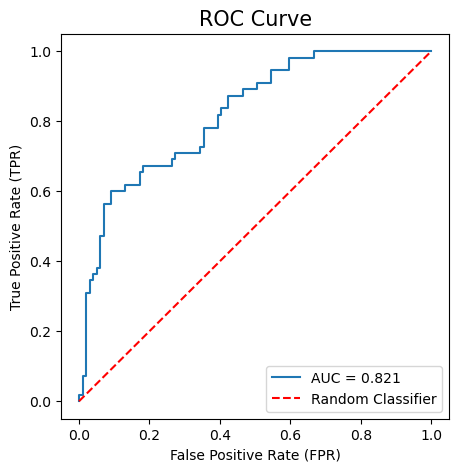

In [36]:
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC - AUC Score:", roc_auc)
plot_roc(y_test, y_prob)

In [37]:
#Coefficient interpretation
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient":model.coef_[0]
})
coef.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
6,DiabetesPedigreeFunction,0.553774
5,BMI,0.101803
0,Pregnancies,0.067595
1,Glucose,0.037338
7,Age,0.034614
3,SkinThickness,0.007706
4,Insulin,-0.001669
2,BloodPressure,-0.013234


#### Deployment

In [48]:
import pickle

In [49]:
from pickle import dump

In [50]:
dump(model, open('model.pkl', 'wb'))

In [52]:
with open("diabetes_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as diabetes_model.pkl")

Model saved as diabetes_model.pkl


In [53]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("diabetes_model.pkl", "rb"))

st.set_page_config(page_title="Diabetes Prediction", page_icon="🩺", layout="centered")
st.title("Diabetes Prediction System")
st.subheader("Model: Logistic Regression | Dataset: Pima Indians Diabetes")
st.markdown("Predict whether a patient is **Diabetic (1)** or **Not Diabetic (0)**.")
st.divider()

col1, col2 = st.columns(2)
with col1:
    preg    = st.number_input("Pregnancies",                min_value=0,   step=1,   value=0)
    glucose = st.number_input("Glucose",                    min_value=0.0, value=0.0)
    bp      = st.number_input("Blood Pressure",             min_value=0.0, value=0.0)
    skin    = st.number_input("Skin Thickness",             min_value=0.0, value=0.0)
with col2:
    insulin = st.number_input("Insulin",                    min_value=0.0, value=0.0)
    bmi     = st.number_input("BMI",                        min_value=0.0, value=0.0)
    dpf     = st.number_input("Diabetes Pedigree Function", min_value=0.0, value=0.0)
    age     = st.number_input("Age",                        min_value=0,   step=1,   value=0)

st.divider()

if st.button(" Predict", use_container_width=True):
    input_data = np.array([[preg, glucose, bp, skin, insulin, bmi, dpf, age]])
    prediction  = model.predict(input_data)
    probability = model.predict_proba(input_data)[0]

    if prediction[0] == 1:
        st.error(" Diabetic (1) — The patient is likely Diabetic.")
    else:
        st.success("Not Diabetic (0) — The patient is likely Not Diabetic.")

    col_a, col_b = st.columns(2)
    col_a.metric("Not Diabetic (0) Probability", f"{probability[0]*100:.2f}%")
    col_b.metric("Diabetic (1) Probability",     f"{probability[1]*100:.2f}%")

st.divider()
st.caption("Model: Logistic Regression | Dataset: Pima Indians Diabetes")

Overwriting app.py


In [ ]:
!pip install streamlit

In [ ]:
### STREAMLIT DEPLOYMENT
The Logistic Regression model has been deployed using Streamlit to provide an interactive web application for diabetes prediction.

**Features of the application:**
- Loads the trained Logistic Regression model (`model.pkl`).
- Accepts user inputs for:
  - Pregnancies
  - Glucose
  - Blood Pressure
  - Skin Thickness
  - Insulin
  - BMI
  - Diabetes Pedigree Function
  - Age
- Predicts whether the patient is **Diabetic** or **Not Diabetic**.
- Displays the prediction through an interactive user interface.

**GitHub Repository:**
https://github.com/sandhya-143
    
**Streamlit Deployment:
 https://diabetesprediction-gxkdhvzknqbpbjal67hln8.streamlit.app/

#### Streamlit link: https://diabetesprediction-gxkdhvzknqbpbjal67hln8.streamlit.app/

### Interview Questions

#### 1. What is the difference between Precision and Recall?

##### Precision measures how many positive predictions made by the model are actually correct, while recall measures how many actual positive cases are correctly identified by the model.

#### 2. What is Cross-Validation and Why is it Important in Binary Classification?



##### Cross-validation is a technique used to evaluate a model by testing it on different subsets of data. It helps improve reliability, reduces overfitting, and provides a better estimate of model performance on unseen data